# Theoretical Formulation and Reward Engineering

The R1-Zero recipe relies on an extremely lean reward function composed of two main signals:

- Accuracy rewards
- Format rewards

```text
Total Reward R_total
├── Accuracy Reward R_acc
└── Format Reward R_fmt
```

## 1. Accuracy Reward ($R_{\text{acc}}$)

For deterministic tasks such as mathematics, symbolic logic, or coding, human raters or LLM judges are replaced by rule-based verification engines.

### Examples

- Math problems: parse the final answer using regular expressions and compare it to the ground-truth scalar value.
- Code synthesis: run the generated code in a Python sandbox and execute unit tests.

A common formulation is:

$$
R_{\text{acc}}(y) =
\begin{cases}
1.0 & \text{if } \text{parse}(y) = y_{\text{truth}} \\
0.0 & \text{otherwise}
\end{cases}
$$

## 2. Format Reward ($R_{\text{fmt}}$)

To ensure structural readability without telling the model exactly what to write inside its reasoning, a lightweight formatting constraint is applied.

$$
R_{\text{fmt}}(y) =
\begin{cases}
0.1 & \text{if output matches the pattern } \texttt{<think>...</think><answer>...</answer>} \\
0.0 & \text{otherwise}
\end{cases}
$$

## Total Trajectory Reward

The total reward is simply:

$$
R_{\text{total}} = R_{\text{acc}} + R_{\text{fmt}}
$$


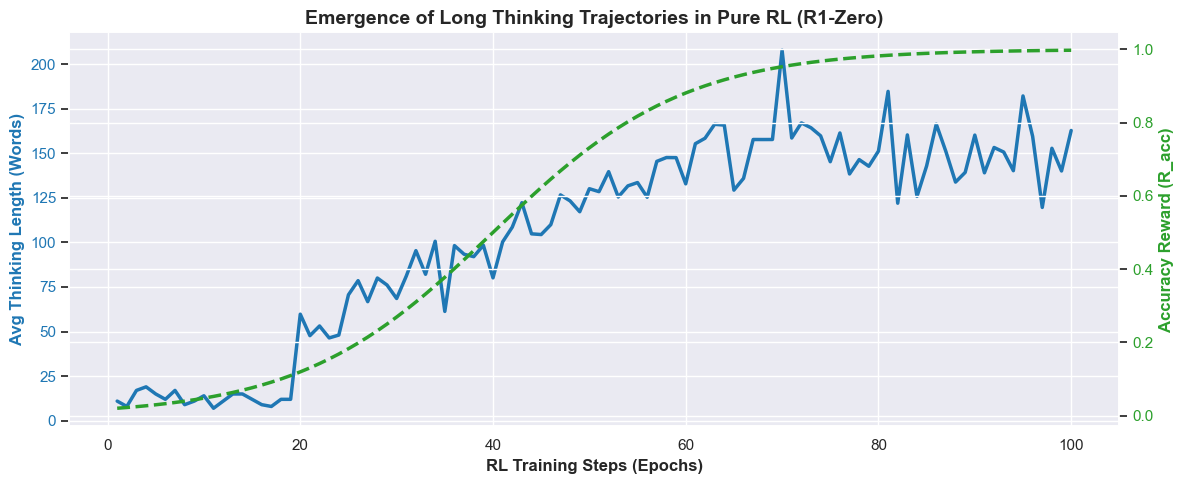

In [2]:
import re
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


class VerifiableRewardEngine:
    """
    Rule-based reward engine for Pure RL (R1-Zero style).
    Scores completions deterministically without requiring a neural Reward Model.
    """
    def __init__(self, format_reward_weight: float = 0.1):
        self.fmt_weight = format_reward_weight
        # Regex to match strict <think>...</think><answer>...</answer> format
        self.format_pattern = re.compile(
            r"^\s*<think>(.*?)</think>\s*<answer>(.*?)</answer>\s*$", 
            re.DOTALL
        )

    def evaluate_completion(self, completion_text: str, ground_truth_answer: str) -> dict:
        r_fmt = 0.0
        r_acc = 0.0
        
        # 1. Format Verification
        match = self.format_pattern.match(completion_text)
        if match:
            r_fmt = self.fmt_weight
            thinking_content = match.group(1).strip()
            answer_content = match.group(2).strip()
        else:
            thinking_content = ""
            answer_content = completion_text.strip()

        # 2. Accuracy Verification (Parsing extracted answer)
        # Clean answer text to compare scalar math results
        clean_answer = re.sub(r"[^\d.-]", "", answer_content)
        clean_truth = re.sub(r"[^\d.-]", "", ground_truth_answer)
        
        if clean_answer and clean_truth and clean_answer == clean_truth:
            r_acc = 1.0

        total_reward = r_acc + r_fmt
        thinking_length = len(thinking_content.split())
        
        return {
            "total_reward": total_reward,
            "r_acc": r_acc,
            "r_fmt": r_fmt,
            "thinking_length": thinking_length,
            "has_self_correction": "wait" in thinking_content.lower() or "check" in thinking_content.lower()
        }


# --- SIMULATION OF R1-ZERO EMERGENT METRICS ---
np.random.seed(42)
steps = np.arange(1, 101)

# Simulated metrics over 100 training iterations
thinking_lengths = np.where(steps < 20, np.random.randint(5, 20, 100), 
                   np.where(steps < 60, steps * 2.5 + np.random.normal(0, 10, 100),
                            150 + np.random.normal(0, 15, 100)))

accuracy_rates = 1 / (1 + np.exp(-(steps - 40) / 10)) # Sigmoid accuracy curve

# Visualization
sns.set_theme(style="darkgrid")
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('RL Training Steps (Epochs)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Avg Thinking Length (Words)', color=color, fontsize=12, fontweight='bold')
line1 = ax1.plot(steps, thinking_lengths, color=color, linewidth=2.5, label='Thinking Length (<think>)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:green'
ax2.set_ylabel('Accuracy Reward (R_acc)', color=color, fontsize=12, fontweight='bold')
line2 = ax2.plot(steps, accuracy_rates, color=color, linewidth=2.5, linestyle='--', label='Accuracy Rate')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Emergence of Long Thinking Trajectories in Pure RL (R1-Zero)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()